<h1><center>Churn Prediction (Statistical Testing, Stacking Ensemble) </center></h1>

<center><img src="https://uploads-ssl.webflow.com/60d45d63543dd9baaad4cb28/60d85fd90743e2299c711be5_1%20dqSLRSEC2GDV9bw_PplCYQ.png" align="center"/></center>

<a id='7'></a>
# 7 Multivariate Analysis

<a id='7.1'></a>
### 7.1 Multicollinearity (Kruskal–Wallis)


The test is more commonly used when we have **three or more levels**. For two levels, the **Mann Whitney U Test** is appropriate 

The **parametric equivalent of the Kruskal–Wallis test** is the one-way analysis of variance (ANOVA)

Hypothses - 

* Fail to Reject H0: All sample distributions are equal.
* Reject H0: One or more sample distributions are not equal.


In [81]:
# compare samples
stat, p = stats.kruskal(df_churn['TotalCharges'], df_churn['tenure'], df_churn['MonthlyCharges'])
print('Statistics=%.3f, p=%.3f' % (stat, p))
# interpret
alpha = 0.05
if p > alpha:
	print('Same distributions (fail to reject H0)')
else:
	print('Different distributions (reject H0)')

Statistics=13184.759, p=0.000
Different distributions (reject H0)


In [82]:
# compare samples
stat, p = stats.kruskal(df_churn['DeviceProtection'], df_churn['StreamingMovies'], df_churn['PhoneService'])
print('Statistics=%.3f, p=%.3f' % (stat, p))
# interpret
alpha = 0.05
if p > alpha:
	print('Same distributions (fail to reject H0)')
else:
	print('Different distributions (reject H0)')

Statistics=4696.340, p=0.000
Different distributions (reject H0)


In [83]:
# compare samples
stat, p = stats.kruskal(df_churn['Contract'], df_churn['PaymentMethod'], df_churn['PhoneService'], df_churn['InternetService'])
print('Statistics=%.3f, p=%.3f' % (stat, p))
# interpret
alpha = 0.05
if p > alpha:
	print('Same distributions (fail to reject H0)')
else:
	print('Different distributions (reject H0)')

Statistics=22407.812, p=0.000
Different distributions (reject H0)


<a id='7.2'></a>
## 7.2 Frequency Distribution

In [84]:
def multivariate_analysis(cat_var_1, cat_var_2, cat_var_3, target_variable=df_churn.Churn):
    
    fig,ax = plt.subplots(1,1,figsize = (18,5))
    font_size = 15
    cat_grouped_by_cat_target = pd.crosstab(index = [cat_var_1, cat_var_2, cat_var_3],
                                        columns = target_variable, normalize = "index")*100                            
    cat_grouped_by_cat_target.rename({"Yes":"% Churn", "No":"% Not Churn"}, axis = 1, inplace = True)
    cat_grouped_by_cat_target.plot.bar(color = ["green", "red"],ax=ax)
    ax.set_xlabel(f"{cat_var_1.name}, {cat_var_2.name}, {cat_var_3.name}", fontsize = font_size)
    ax.set_ylabel("Relative Frequency(%)", fontsize = font_size)
    ax.tick_params(axis="x", labelsize=font_size)
    ax.tick_params(axis="y", labelsize=font_size)
    plt.legend(loc = "best")
    return plt.show()

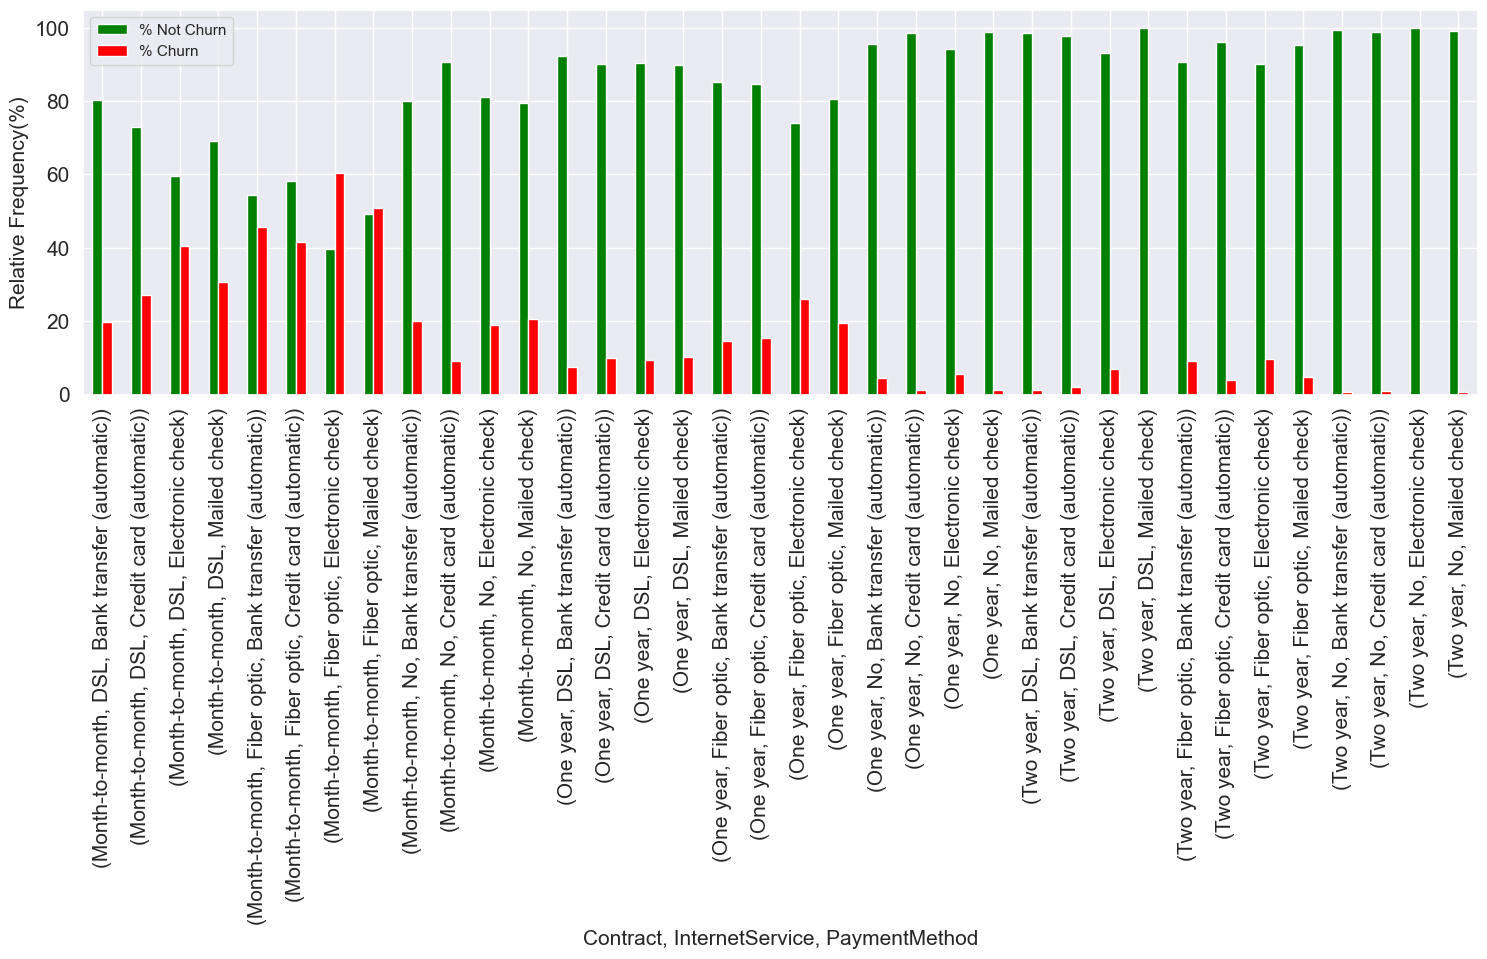

### Findings: Most of the users who churned had a Month-to-month contract and had internet service

In [85]:
multivariate_analysis(df_churn.Contract, df_churn.InternetService, df_churn.PaymentMethod)
printmd("### Findings: Most of the users who churned had a Month-to-month contract and had internet service")

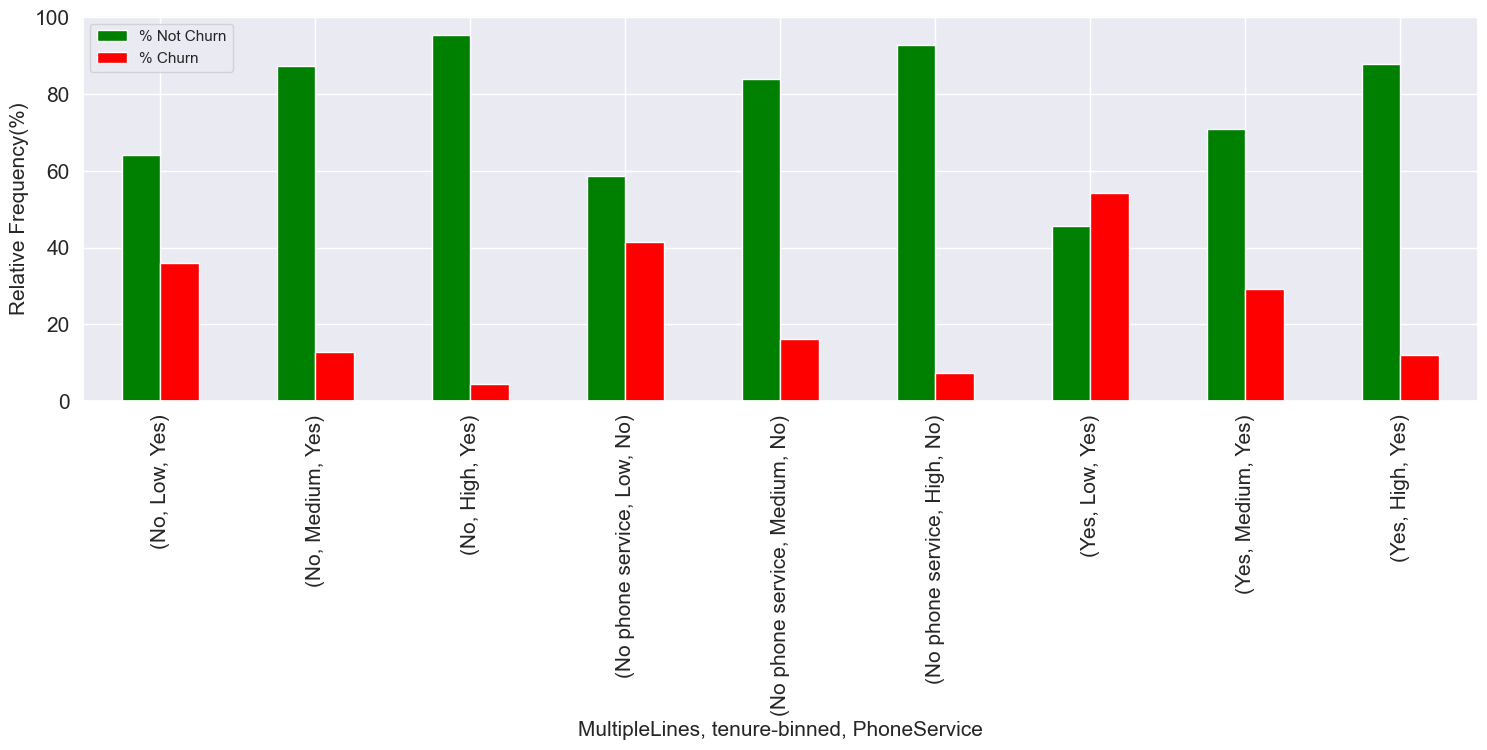

## Findings: Most of the users who churned had phone service

In [86]:
multivariate_analysis(df_churn.MultipleLines, df_churn['tenure-binned'], df_churn.PhoneService)
printmd("## Findings: Most of the users who churned had phone service")

<a id='7.3'></a>
## 7.3 Churn Count Distribution

In [87]:
def plot_counting_distribution(cardinality_value):

  #label encoding binary columns
  le = LabelEncoder()

  tmp_churn = df_churn[df_churn['Churn'] == 'Yes']
  tmp_no_churn = df_churn[df_churn['Churn'] == 'No']

  selected_columns = df_churn.nunique()[df_churn.nunique() == cardinality_value].keys()

  for col in selected_columns :
      tmp_churn[col] = le.fit_transform(tmp_churn[col])
      

  data_frame_x = tmp_churn[selected_columns].sum().reset_index()
  data_frame_x.columns = ["feature","Yes"]
  data_frame_x["No"] = tmp_churn.shape[0]  - data_frame_x["Yes"]
  data_frame_x = data_frame_x[data_frame_x["feature"] != "Churn"]

  #count of 1's(yes)
  trace1 = go.Scatterpolar(r=data_frame_x["Yes"].values.tolist(), 
                          theta=data_frame_x["feature"].tolist(),
                          fill="toself", name="Churn 1's",
                          mode="markers+lines", visible=True,
                          marker=dict(size=5)
                          )

  #count of 0's(No)
  trace2 = go.Scatterpolar(r=data_frame_x["No"].values.tolist(),
                          theta=data_frame_x["feature"].tolist(),
                          fill="toself",name="Churn 0's",
                          mode="markers+lines", visible=True,
                          marker=dict(size = 5)
                          ) 
  for col in selected_columns :
      tmp_no_churn[col] = le.fit_transform(tmp_no_churn[col])
      
  data_frame_x = tmp_no_churn[selected_columns].sum().reset_index()
  data_frame_x.columns  = ["feature","Yes"]
  data_frame_x["No"]    = tmp_no_churn.shape[0]  - data_frame_x["Yes"]
  data_frame_x  = data_frame_x[data_frame_x["feature"] != "Churn"]

  #count of 1's(yes)
  trace3 = go.Scatterpolar(r = data_frame_x["Yes"].values.tolist(),
                          theta = data_frame_x["feature"].tolist(),
                          fill  = "toself",name = "NoChurn 1's",
                          mode = "markers+lines", visible=False,
                          marker = dict(size = 5)
                          )

  #count of 0's(No)
  trace4 = go.Scatterpolar(r = data_frame_x["No"].values.tolist(),
                          theta = data_frame_x["feature"].tolist(),
                          fill  = "toself",name = "NoChurn 0's",
                          mode = "markers+lines", visible=False,
                          marker = dict(size = 5)
                          ) 

  data = [trace1, trace2, trace3, trace4]

  updatemenus = list([
      dict(active=0,
          x=-0.15,
          buttons=list([  
              dict(
                  label = 'Churn Dist',
                  method = 'update',
                  args = [{'visible': [True, True, False, False]}, 
                      {'title': f'Customer Churn Binary Counting Distribution' }]),
              
              dict(
                    label = 'No-Churn Dist',
                  method = 'update',
                  args = [{'visible': [False, False, True, True]},
                      {'title': f'No Customer Churn Binary Counting Distribution'}]),

          ]),
      )
  ])

  layout = dict(title='ScatterPolar Distribution of Churn and Non-Churn Customers (Select from Dropdown)', 
                showlegend=False,
                updatemenus=updatemenus)

  fig = dict(data=data, layout=layout)

  pio.show(fig)

# Thanks to : https://www.kaggle.com/kabure/insightful-eda-churn-customers-models-pipeline#Feature-Engineering

<a id='7.3.1'></a>
###  7.3.1 Features With Cardinality = 2

In [88]:
plot_counting_distribution(2)

<a id='7.3.2'></a>
###  7.3.2 Features With Cardinality = 3

In [89]:
plot_counting_distribution(3)